In [ ]:
# Paramdeep Choudhary
# cu24250162

Libraries imported successfully!
Upload an image:


Saving image.jpg to image.jpg
Image uploaded: image.jpg
Image loaded successfully!
Image size: (853, 1280, 3)
Gaussian Blur applied successfully!


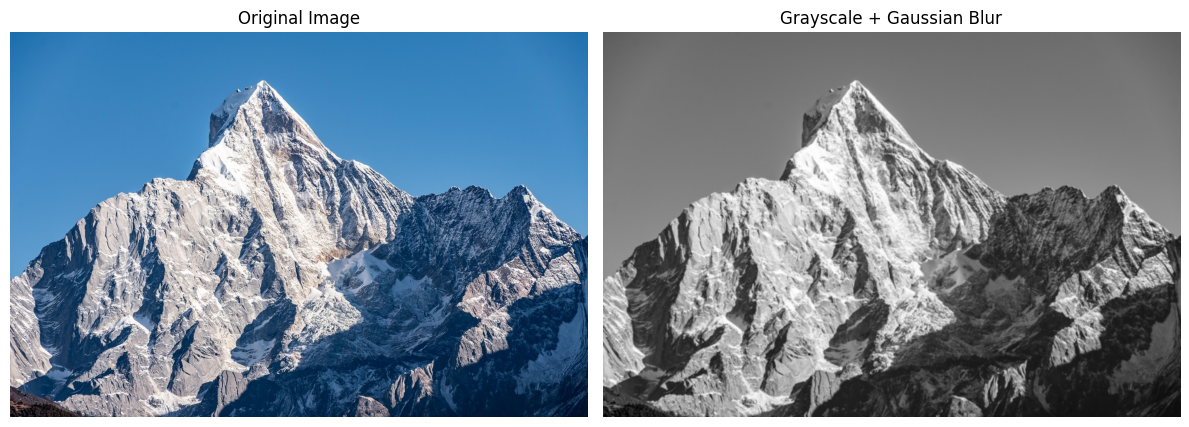

Global Thresholding completed!
Otsu Thresholding completed!
Automatically selected Otsu threshold: 143.0
Adaptive Thresholding completed!


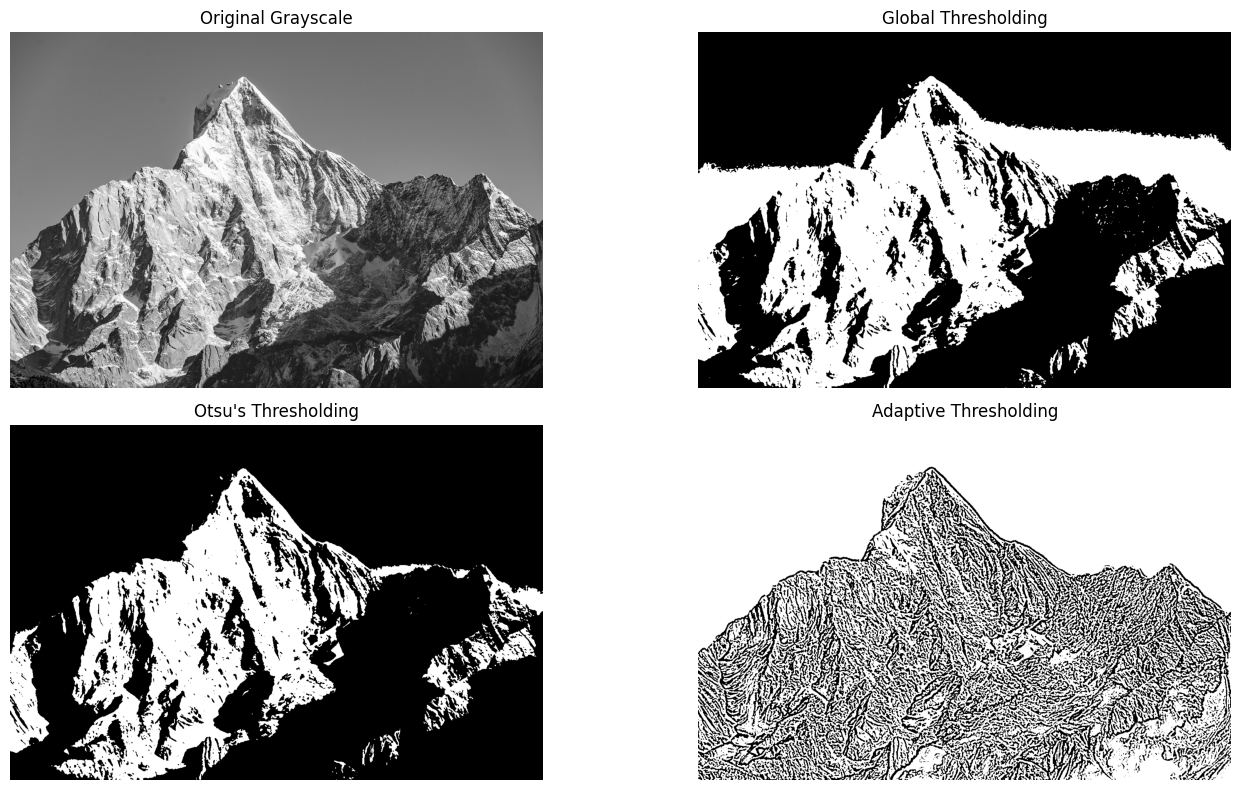

Watershed Segmentation completed!
Number of detected regions: 3


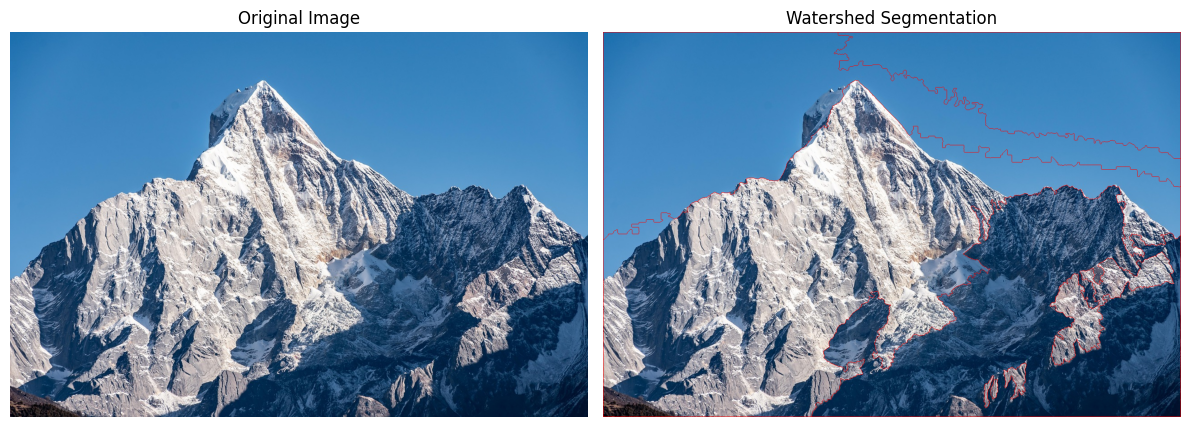

K-Means Clustering completed!
Number of clusters: 4


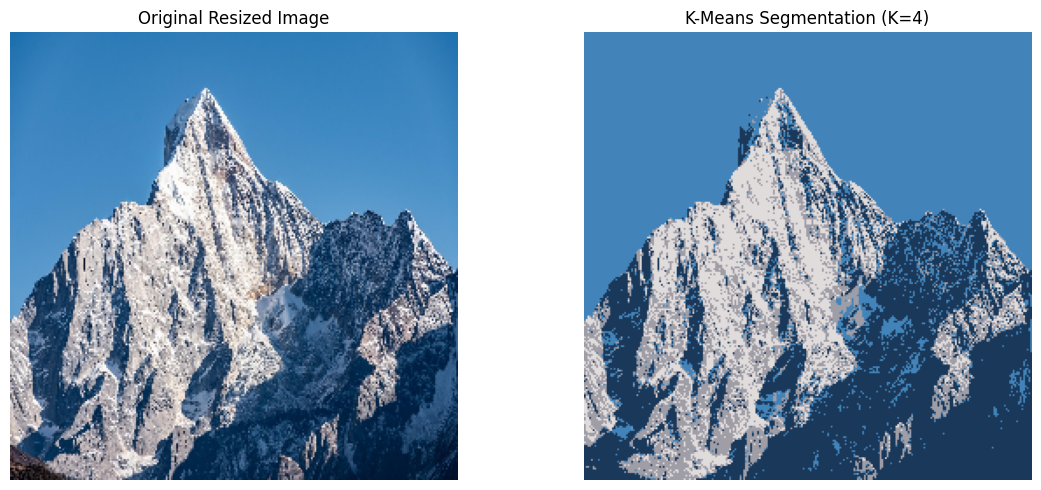

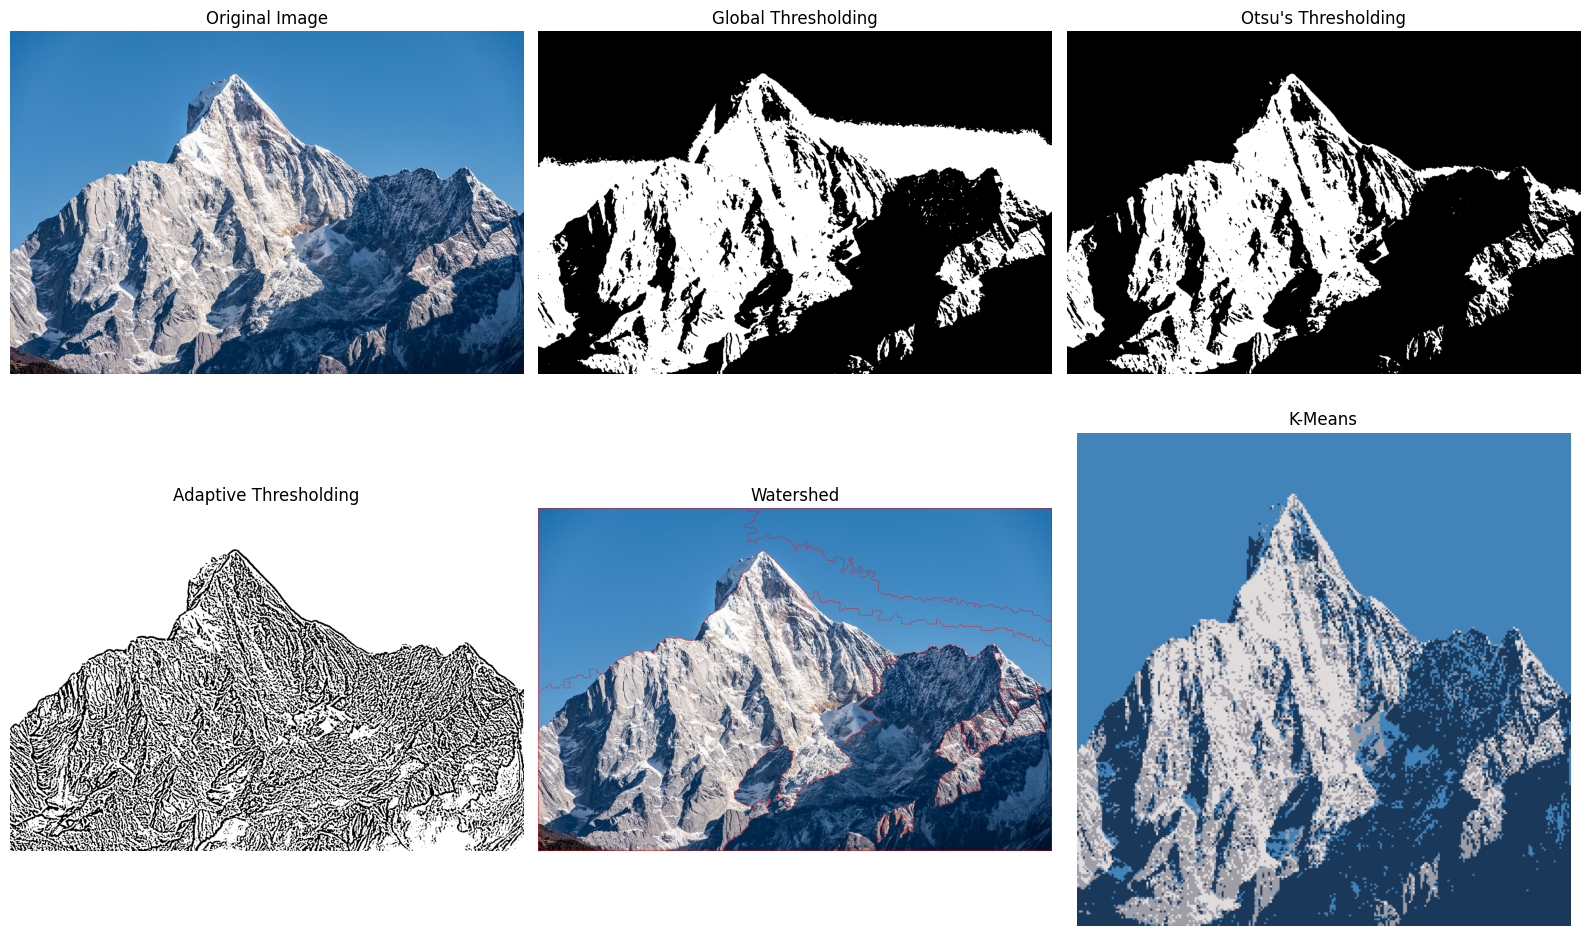


All segmented images saved successfully!

             SEGMENTATION TECHNIQUES COMPARISON

1. Global Thresholding
   - Simple and fast.
   - Works well when foreground and background have
     clear intensity differences.

2. Otsu's Thresholding
   - Automatically selects the threshold.
   - Useful for images with two major intensity regions.

3. Adaptive Thresholding
   - Calculates threshold locally.
   - Works better with uneven illumination.

4. Watershed Segmentation
   - Separates touching or overlapping objects.
   - Useful when individual object boundaries are required.

5. K-Means Clustering
   - Groups pixels based on color similarity.
   - Useful for color-based image segmentation.



                    OBSERVATIONS

1. Image segmentation divides an image into meaningful
   regions or objects.

2. Global Thresholding is simple and computationally fast
   but may not work well with uneven illumination.

3. Otsu's method automatically determines a suitable
   threshold value

In [ ]:
# ============================================================
# EXPERIMENT NO. 6
# IMPLEMENTATION AND COMPARATIVE ANALYSIS OF
# IMAGE SEGMENTATION TECHNIQUES USING PYTHON AND OPENCV
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.cluster import KMeans

print("Libraries imported successfully!")


# ============================================================
# 1. UPLOAD IMAGE
# ============================================================

print("Upload an image:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Image uploaded:", filename)


# ============================================================
# 2. LOAD IMAGE
# ============================================================

image = cv2.imread(filename)

if image is None:
    raise Exception("Image could not be loaded.")

# Convert BGR to RGB for displaying
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Image loaded successfully!")
print("Image size:", image.shape)


# ============================================================
# 3. GAUSSIAN BLUR / PREPROCESSING
# ============================================================

blurred = cv2.GaussianBlur(
    gray,
    (5, 5),
    0
)

print("Gaussian Blur applied successfully!")


# ============================================================
# 4. DISPLAY ORIGINAL AND GRAYSCALE IMAGE
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(blurred, cmap="gray")
plt.title("Grayscale + Gaussian Blur")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 5. GLOBAL THRESHOLDING
# ============================================================

# Use a fixed threshold value
threshold_value = 127

_, global_threshold = cv2.threshold(
    blurred,
    threshold_value,
    255,
    cv2.THRESH_BINARY
)

print("Global Thresholding completed!")


# ============================================================
# 6. OTSU'S THRESHOLDING
# ============================================================

otsu_threshold_value, otsu_threshold = cv2.threshold(
    blurred,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu Thresholding completed!")
print("Automatically selected Otsu threshold:",
      otsu_threshold_value)


# ============================================================
# 7. ADAPTIVE THRESHOLDING
# ============================================================

adaptive_threshold = cv2.adaptiveThreshold(
    blurred,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

print("Adaptive Thresholding completed!")


# ============================================================
# 8. DISPLAY THRESHOLDING RESULTS
# ============================================================

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(global_threshold, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(adaptive_threshold, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 9. WATERSHED SEGMENTATION
# ============================================================

# Start with Otsu threshold
binary = otsu_threshold.copy()

# Make sure foreground is white
white_pixels = np.sum(binary == 255)
black_pixels = np.sum(binary == 0)

if white_pixels < black_pixels:
    binary = cv2.bitwise_not(binary)

# Remove small noise using opening
kernel = np.ones((3, 3), np.uint8)

opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel,
    iterations=2
)

# Sure background
sure_bg = cv2.dilate(
    opening,
    kernel,
    iterations=3
)

# Distance transform
dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

# Sure foreground
_, sure_fg = cv2.threshold(
    dist_transform,
    0.5 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

# Unknown region
unknown = cv2.subtract(
    sure_bg,
    sure_fg
)

# Marker labelling
num_labels, markers = cv2.connectedComponents(
    sure_fg
)

# Add 1 so that background becomes 1
markers = markers + 1

# Mark unknown region as 0
markers[unknown == 255] = 0

# Apply Watershed
watershed_image = image.copy()

markers = cv2.watershed(
    watershed_image,
    markers
)

# Mark watershed boundaries in red
watershed_result = image_rgb.copy()

watershed_result[markers == -1] = [255, 0, 0]

print("Watershed Segmentation completed!")
print("Number of detected regions:",
      num_labels - 1)


# ============================================================
# 10. DISPLAY WATERSHED RESULT
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(watershed_result)
plt.title("Watershed Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 11. K-MEANS COLOR SEGMENTATION
# ============================================================

# Resize image to reduce computation
small_image = cv2.resize(
    image_rgb,
    (256, 256)
)

# Convert pixels into a 2D array
pixels = small_image.reshape(
    (-1, 3)
)

pixels = np.float32(pixels)

# Number of clusters
k = 4

# Create K-Means model
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# Train K-Means
kmeans.fit(pixels)

# Get cluster centers
centers = np.uint8(
    kmeans.cluster_centers_
)

# Get cluster labels
labels = kmeans.labels_

# Replace every pixel with its cluster center
segmented_pixels = centers[labels]

# Reshape back into image
kmeans_segmented = segmented_pixels.reshape(
    small_image.shape
)

print("K-Means Clustering completed!")
print("Number of clusters:", k)


# ============================================================
# 12. DISPLAY K-MEANS SEGMENTATION
# ============================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(small_image)
plt.title("Original Resized Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(kmeans_segmented)
plt.title("K-Means Segmentation (K=4)")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 13. COMPLETE COMPARISON
# ============================================================

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(global_threshold, cmap="gray")
plt.title("Global Thresholding")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(otsu_threshold, cmap="gray")
plt.title("Otsu's Thresholding")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(adaptive_threshold, cmap="gray")
plt.title("Adaptive Thresholding")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(watershed_result)
plt.title("Watershed")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(kmeans_segmented)
plt.title("K-Means")
plt.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 14. SAVE OUTPUT IMAGES
# ============================================================

cv2.imwrite(
    "global_threshold.jpg",
    global_threshold
)

cv2.imwrite(
    "otsu_threshold.jpg",
    otsu_threshold
)

cv2.imwrite(
    "adaptive_threshold.jpg",
    adaptive_threshold
)

cv2.imwrite(
    "watershed_result.jpg",
    cv2.cvtColor(
        watershed_result,
        cv2.COLOR_RGB2BGR
    )
)

cv2.imwrite(
    "kmeans_segmented.jpg",
    cv2.cvtColor(
        kmeans_segmented,
        cv2.COLOR_RGB2BGR
    )
)

print("\nAll segmented images saved successfully!")


# ============================================================
# 15. COMPARISON TABLE
# ============================================================

print("""
============================================================
             SEGMENTATION TECHNIQUES COMPARISON
============================================================

1. Global Thresholding
   - Simple and fast.
   - Works well when foreground and background have
     clear intensity differences.

2. Otsu's Thresholding
   - Automatically selects the threshold.
   - Useful for images with two major intensity regions.

3. Adaptive Thresholding
   - Calculates threshold locally.
   - Works better with uneven illumination.

4. Watershed Segmentation
   - Separates touching or overlapping objects.
   - Useful when individual object boundaries are required.

5. K-Means Clustering
   - Groups pixels based on color similarity.
   - Useful for color-based image segmentation.

============================================================
""")


# ============================================================
# 16. OBSERVATIONS
# ============================================================

print("""
============================================================
                    OBSERVATIONS
============================================================

1. Image segmentation divides an image into meaningful
   regions or objects.

2. Global Thresholding is simple and computationally fast
   but may not work well with uneven illumination.

3. Otsu's method automatically determines a suitable
   threshold value.

4. Adaptive Thresholding performs better when illumination
   varies across the image.

5. Watershed segmentation is useful for separating
   touching or overlapping objects.

6. K-Means segmentation groups pixels according to
   their color characteristics.

7. Thresholding methods are mainly suitable for images
   with clear foreground and background intensity.

8. K-Means is useful for color-based segmentation.

9. Watershed can provide better object boundaries when
   objects are touching.

10. The most suitable segmentation method depends on
    image characteristics and the application.

============================================================
              EXPERIMENT COMPLETED SUCCESSFULLY
============================================================
""")